Accuracy: 0.84

Classification Report:
              precision  recall  f1-score   support
0                 0.863   0.962     0.910  34071.00
1                 0.478   0.185     0.267   6379.00
accuracy          0.840   0.840     0.840      0.84
macro avg         0.671   0.574     0.588  40450.00
weighted avg      0.802   0.840     0.809  40450.00


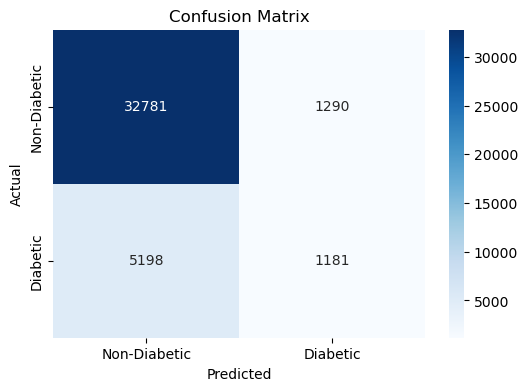

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dmafterprocess.csv")  # Adjust the path if needed

# Convert target to binary: 0 = Non-diabetic, 1 = Pre-diabetic or Diabetic
df['Diabetes_Binary'] = df['Diabetes_012'].apply(lambda x: 0 if x == 0 else 1)

# Define features (X) and target (y)
X = df.drop(columns=['Diabetes_012', 'Diabetes_Binary'])  # drop original and new target
y = df['Diabetes_Binary']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 3))

# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
print("\nClassification Report:")
print(report_df)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Diabetic", "Diabetic"], yticklabels=["Non-Diabetic", "Diabetic"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Accuracy: 0.84


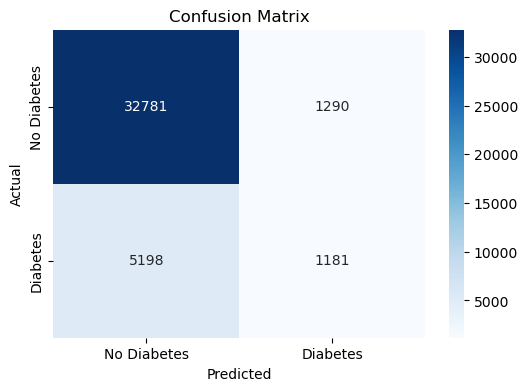

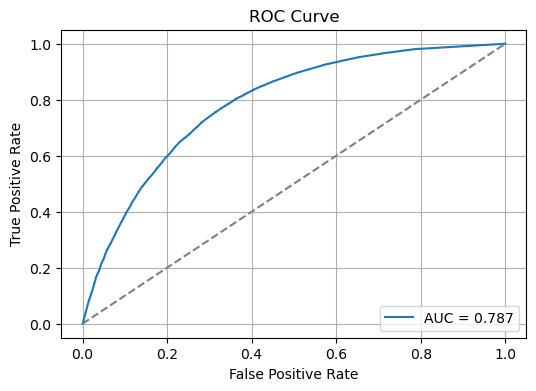

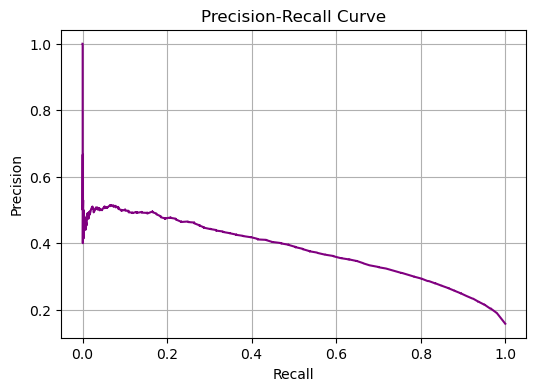

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dmafterprocess.csv")  # Adjust path if needed

# Create binary target
df['Diabetes_Binary'] = df['Diabetes_012'].apply(lambda x: 0 if x == 0 else 1)

# Define features and target
X = df.drop(columns=['Diabetes_012', 'Diabetes_Binary'])
y = df['Diabetes_Binary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# --- 3. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()


<Figure size 1000x600 with 0 Axes>

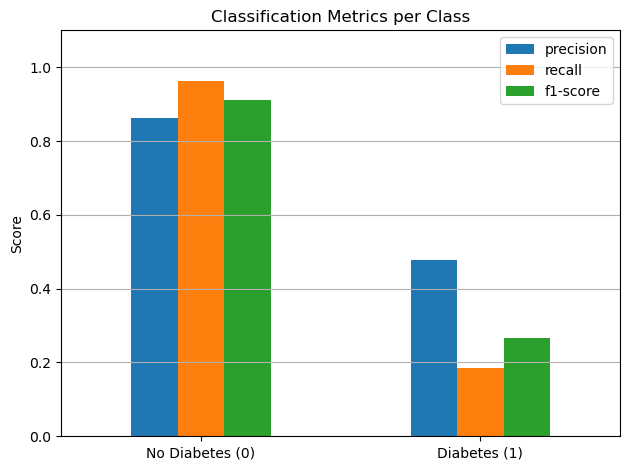


Support (number of samples in test set):
No Diabetes (0)    34071.0
Diabetes (1)        6379.0
Name: support, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Predict again (if not already done)
y_pred = rf.predict(X_test)

# Get classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame
metrics_df = pd.DataFrame(report).transpose().loc[['0', '1']]  # Only keep class 0 and 1
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df.index = ['No Diabetes (0)', 'Diabetes (1)']

# Plotting
plt.figure(figsize=(10, 6))
metrics_df[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title("Classification Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Optional: Print support counts
print("\nSupport (number of samples in test set):")
print(metrics_df['support'])


Accuracy: 0.84

Classification Report:
              precision  recall  f1-score   support
0                 0.863   0.962     0.910  34071.00
1                 0.478   0.185     0.267   6379.00
accuracy          0.840   0.840     0.840      0.84
macro avg         0.671   0.574     0.588  40450.00
weighted avg      0.802   0.840     0.809  40450.00


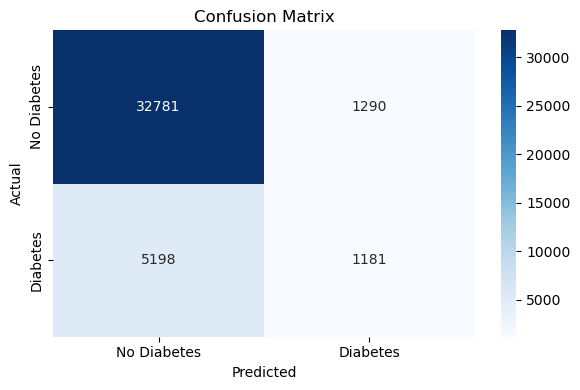

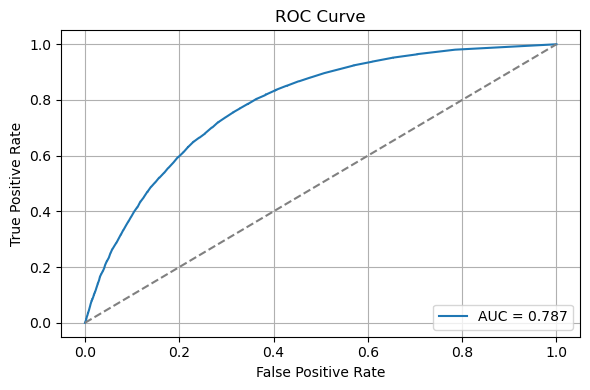

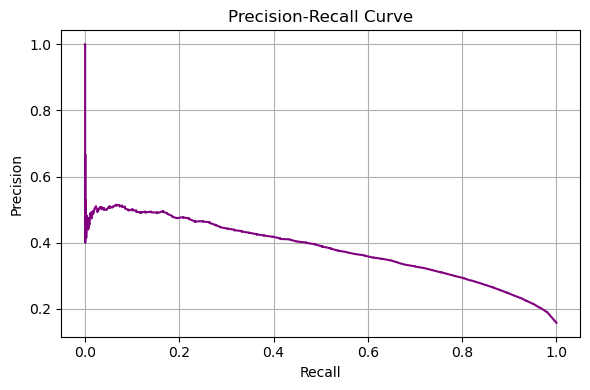

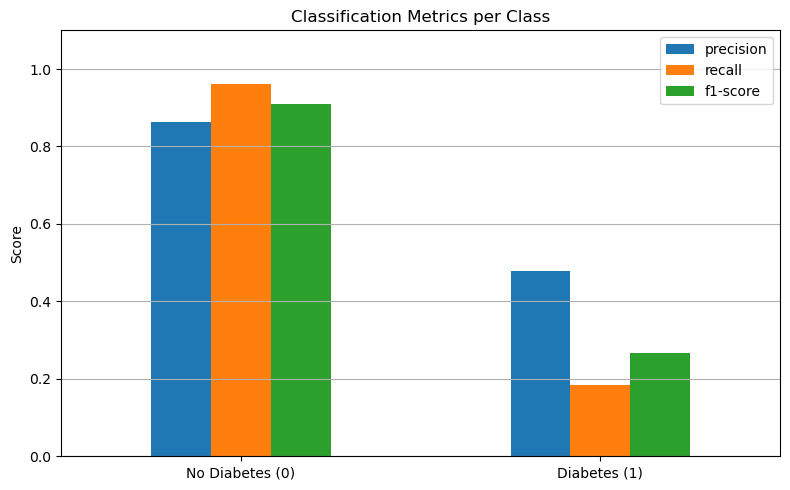

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# Load your cleaned dataset
df = pd.read_csv("dmafterprocess.csv")  # Adjust path if needed

# Target column is now binary (0 = No diabetes, 1 = Diabetes or Pre-diabetes)
y = df["Diabetes_012"]
X = df.drop(columns=["Diabetes_012"])

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Print Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
print("\nClassification Report:")
print(report_df)

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4. Bar Chart: Precision, Recall, F1-score per Class ---
metrics_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
metrics_df.index = ['No Diabetes (0)', 'Diabetes (1)']

metrics_df.plot(kind='bar', figsize=(8, 5))
plt.title("Classification Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Accuracy: 0.679

Classification Report:
              precision  recall  f1-score    support
0                 0.923   0.676     0.780  34071.000
1                 0.287   0.697     0.407   6379.000
accuracy          0.679   0.679     0.679      0.679
macro avg         0.605   0.687     0.593  40450.000
weighted avg      0.822   0.679     0.721  40450.000


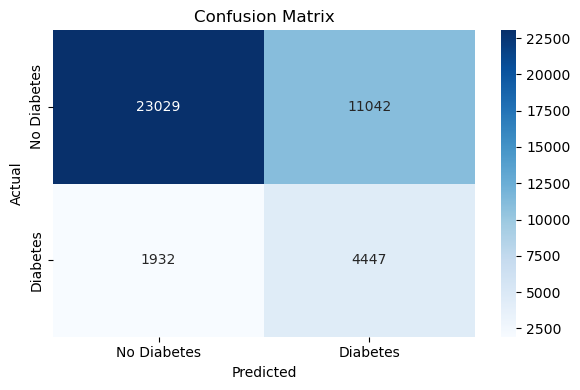

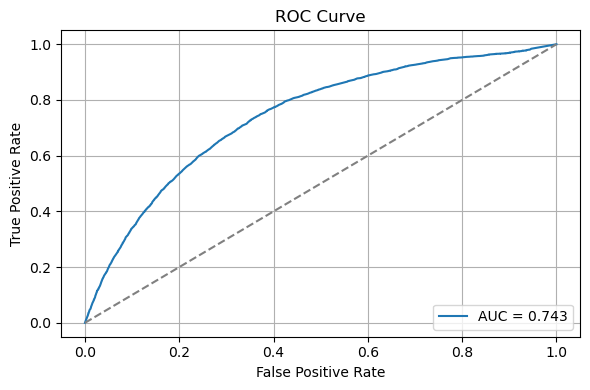

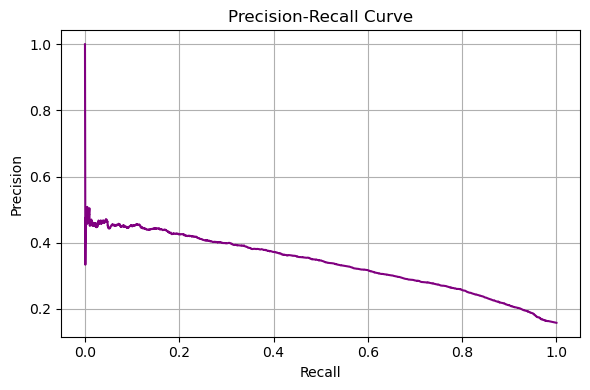

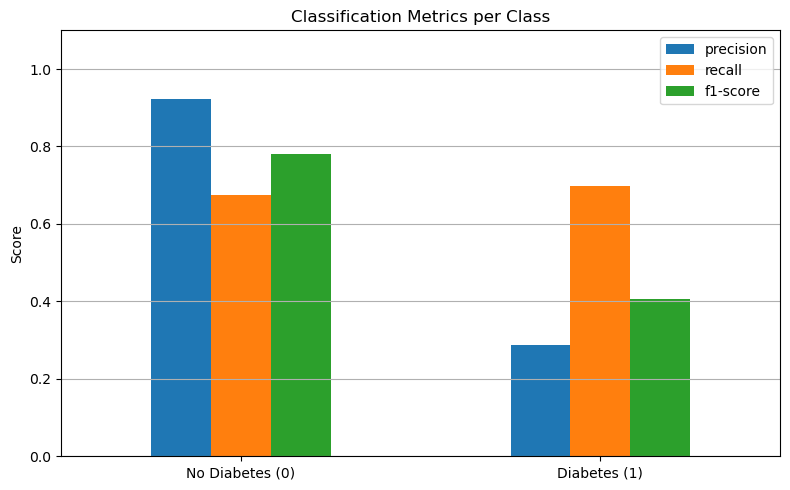

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# Load the dataset
df = pd.read_csv("dmafterprocess.csv")  # Update path if needed

# Binary target (already updated to 0 or 1)
y = df["Diabetes_012"]

# Select lifestyle-related features
lifestyle_features = [
    "Smoker", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
    "BMI", "GenHlth", "DiffWalk"
]
X = df[lifestyle_features]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# Classification report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
print("\nClassification Report:")
print(report_df)

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4. Bar Chart: Metrics per Class ---
metrics_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
metrics_df.index = ['No Diabetes (0)', 'Diabetes (1)']

metrics_df.plot(kind='bar', figsize=(8, 5))
plt.title("Classification Metrics per Class")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



--- Evaluating for Male ---
Accuracy (Male): 0.828
              precision  recall  f1-score    support
0                 0.854   0.957     0.902  14814.000
1                 0.478   0.194     0.276   3018.000
accuracy          0.828   0.828     0.828      0.828
macro avg         0.666   0.575     0.589  17832.000
weighted avg      0.790   0.828     0.796  17832.000


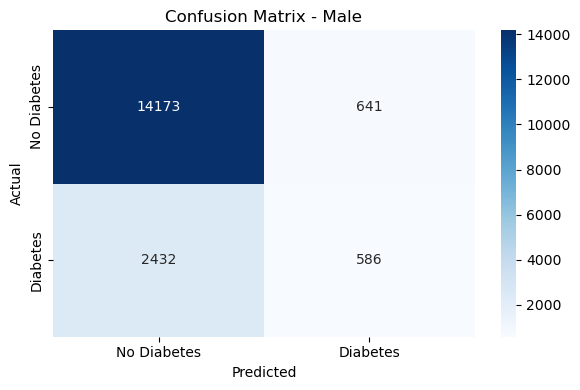

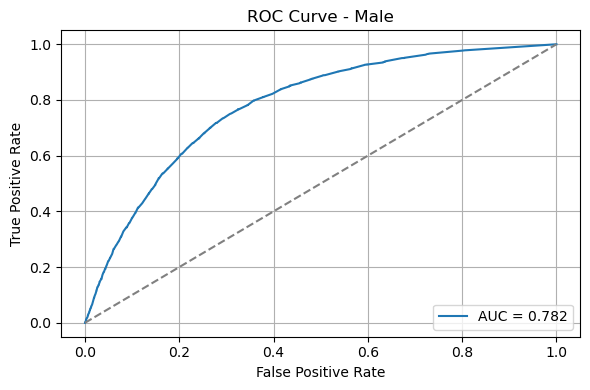

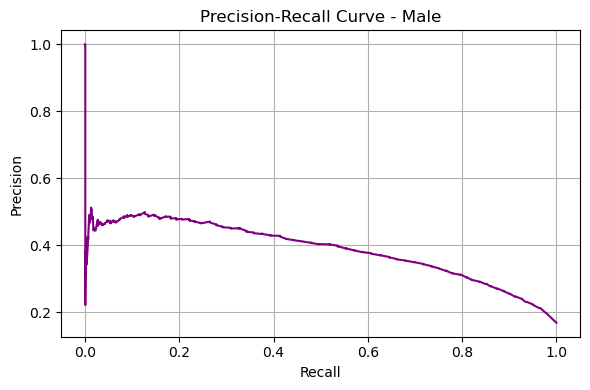

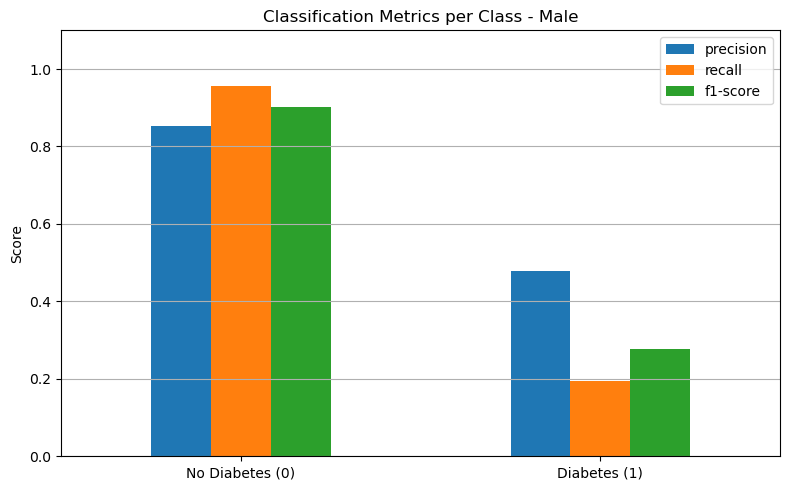


--- Evaluating for Female ---
Accuracy (Female): 0.848
              precision  recall  f1-score    support
0                 0.870   0.967     0.916  19258.000
1                 0.471   0.169     0.249   3361.000
accuracy          0.848   0.848     0.848      0.848
macro avg         0.670   0.568     0.582  22619.000
weighted avg      0.810   0.848     0.817  22619.000


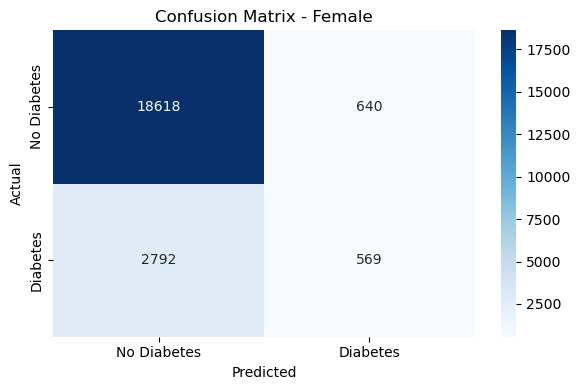

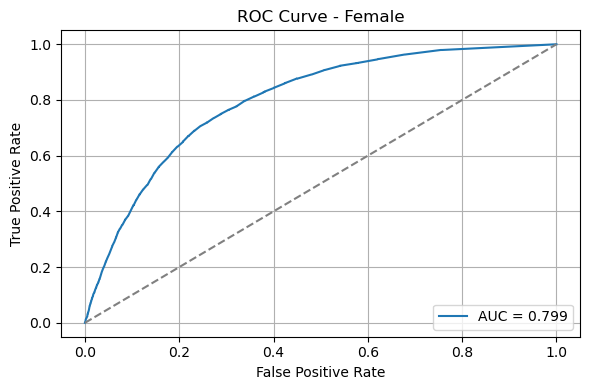

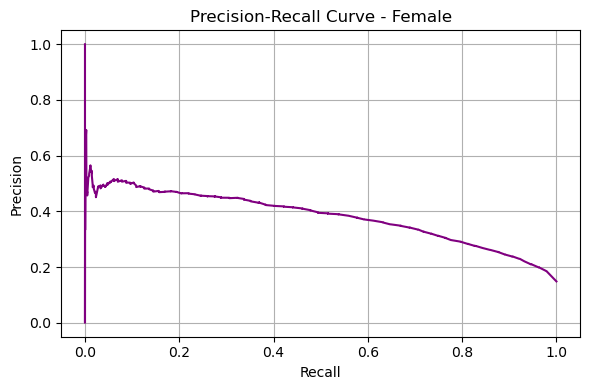

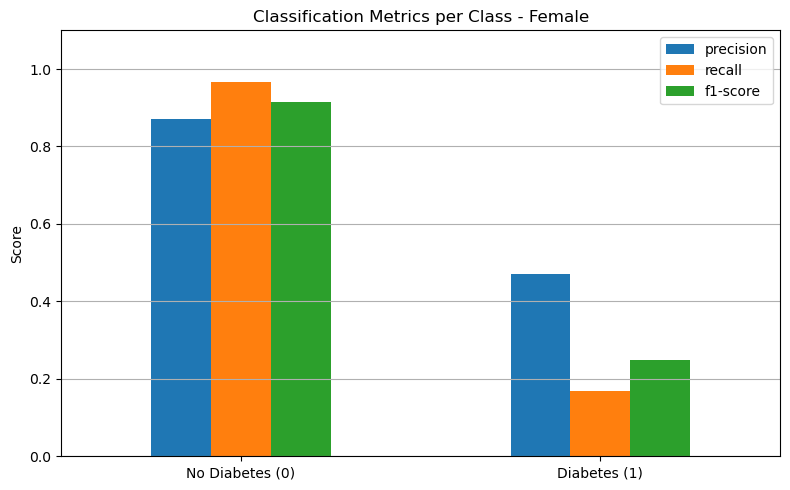

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, precision_recall_curve
)

# Load the dataset
df = pd.read_csv("dmafterprocess.csv")  # Update path as needed

# Ensure binary diabetes target (0 = no diabetes, 1 = diabetes or pre-diabetes)
y_col = "Diabetes_012"
feature_cols = [col for col in df.columns if col not in [y_col]]

# Define a reusable function for evaluation and charting
def evaluate_gender_subset(gender_label, df_subset):
    print(f"\n--- Evaluating for {gender_label} ---")

    X = df_subset.drop(columns=[y_col])
    y = df_subset[y_col]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train model
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = round(accuracy_score(y_test, y_pred), 3)
    print(f"Accuracy ({gender_label}):", acc)

    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(3)
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    plt.title(f"Confusion Matrix - {gender_label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {gender_label}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, color='purple')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {gender_label}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Bar chart of metrics
    metrics_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
    metrics_df.index = ['No Diabetes (0)', 'Diabetes (1)']
    metrics_df.plot(kind='bar', figsize=(8, 5))
    plt.title(f"Classification Metrics per Class - {gender_label}")
    plt.ylabel("Score")
    plt.ylim(0, 1.1)
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Split data by gender
df_male = df[df["Sex"] == 1]   # Assuming 1 = Male
df_female = df[df["Sex"] == 0] # Assuming 0 = Female

# Run evaluation for both genders
evaluate_gender_subset("Male", df_male)
evaluate_gender_subset("Female", df_female)


In [20]:
pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
    --------------------------------------- 3.4/150.0 MB 20.2 MB/s eta 0:00:08
   -- ------------------------------------- 9.4/150.0 MB 25.6 MB/s eta 0:00:06
   ---- ----------------------------------- 15.5/150.0 MB 26.3 MB/s eta 0:00:06
   ----- ---------------------------------- 21.8/150.0 MB 27.0 MB/s eta 0:00:05
   ------- -------------------------------- 27.5/150.0 MB 27.7 MB/s eta 0:00:05
   --------- ------------------------------ 36.7/150.0 MB 29.5 MB/s eta 0:00:04
   ---------- ----------------------------- 41.2/150.0 MB 28.1 MB/s eta 0:00:04
   ------------ --------------------------- 47.4/150.0 MB 28.2 MB/s eta 0:00:04
   -------------- ------------------------- 55.8/150.0 MB 29.6 MB/s eta 0:00:04
   ----------------- ---------------------- 64.5/150.0 MB 30.7 MB/s eta 0:00:03
   ------------------- -------------------- 72.4/150.0 MB 31.2 MB/s eta 0:00:03
   --------------------- ------------------ 80.5/15

C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:02:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.721

Classification Report:
              precision  recall  f1-score    support
0                 0.946   0.709     0.811  34071.000
1                 0.335   0.784     0.470   6379.000
accuracy          0.721   0.721     0.721      0.721
macro avg         0.641   0.746     0.640  40450.000
weighted avg      0.850   0.721     0.757  40450.000


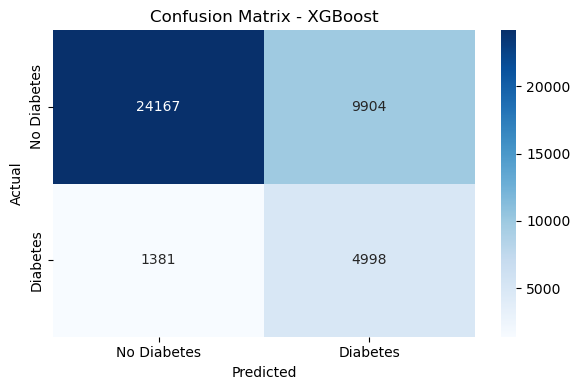

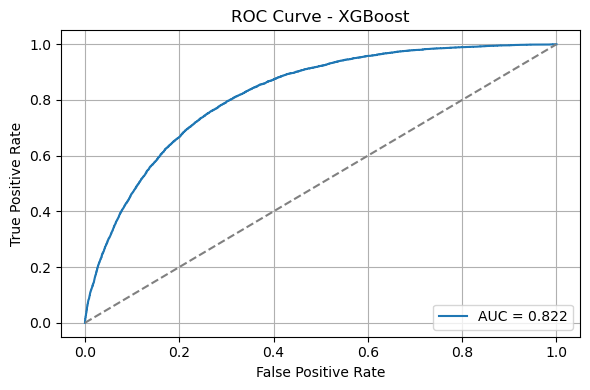

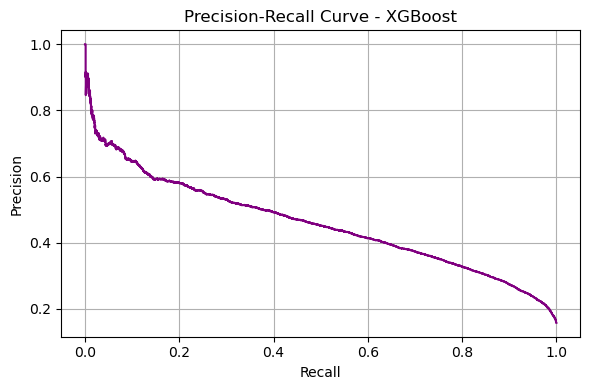

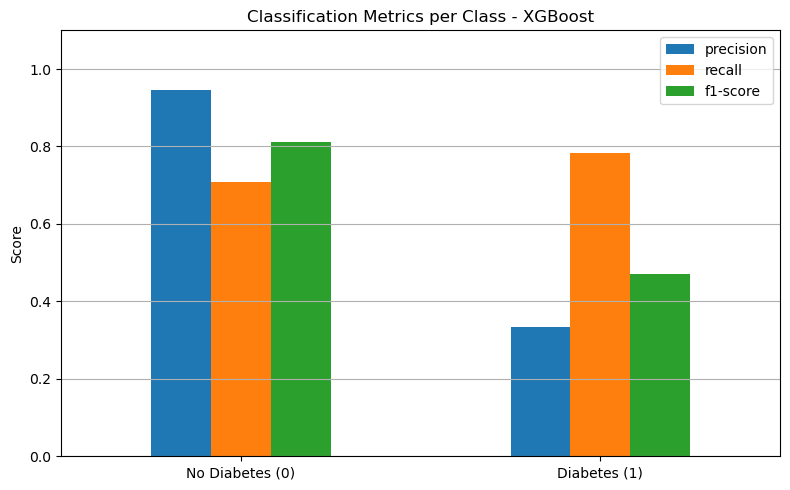

In [21]:
#insight1 using xgboost
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, precision_recall_curve
)
from xgboost import XGBClassifier

# Load the dataset
df = pd.read_csv("dmafterprocess.csv")  # Update path if needed

# Target and features
y = df["Diabetes_012"]
X = df.drop(columns=["Diabetes_012"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train XGBoost classifier
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # class imbalance
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(3)
print("\nClassification Report:")
print(report_df)

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4. Bar Chart: Classification Metrics per Class ---
metrics_df = report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]
metrics_df.index = ['No Diabetes (0)', 'Diabetes (1)']

metrics_df.plot(kind='bar', figsize=(8, 5))
plt.title("Classification Metrics per Class - XGBoost")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
